# Do the exposures travel to the next month?

Freeze a 60-month exposure estimate, supply the next month's realized factors, and measure reconstruction error. Compare ridge's smaller coefficient changes with its uncertain tracking gain and PCR's cost of discarding directions.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'research/models.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
RESULTS = ROOT / 'research/results'
FIGURES = ROOT / 'research/figures'


## Question and timing
The coefficients are fitted through t−1. Factor returns for t are observed afterward and enter the reconstruction. This is a test of exposure portability conditional on realized factors, not an ex ante return forecast. The source files are also revised vintages.

In [2]:
from research.data import load_panel
from research.run_study import rolling_reconstruction, comparison, summarize
x, y, audit = load_panel()
paths = rolling_reconstruction(x, y)
assert (paths.train_end < paths.month).all()
display(summarize(paths).round(4))

,model,months,etfs,rmse_pct_monthly,mse_pp2,rms_beta_monthly_change,mean_effective_df_including_intercept
0,Market,175,10,3.3741,11.3843,0.0090,2.000
1,FF5,175,10,3.0256,9.1540,0.0407,6.000
2,OLS,175,10,3.0288,9.1736,0.0434,7.000
3,Ridge 0.1,175,10,2.9994,8.9964,0.0347,6.153
4,PCR 4,175,10,3.2979,10.8761,0.0854,5.000


## Paired panel comparison
Average squared percentage-point errors equally across all ten funds within each month. Resample those paired months in common 12-month blocks, retaining sector dependence.

,Ridge minus OLS comparison
estimate,-0.177198
lower95,-0.397819
upper95,0.028245
relative_mse_reduction_pct,1.931601
n,175.000000


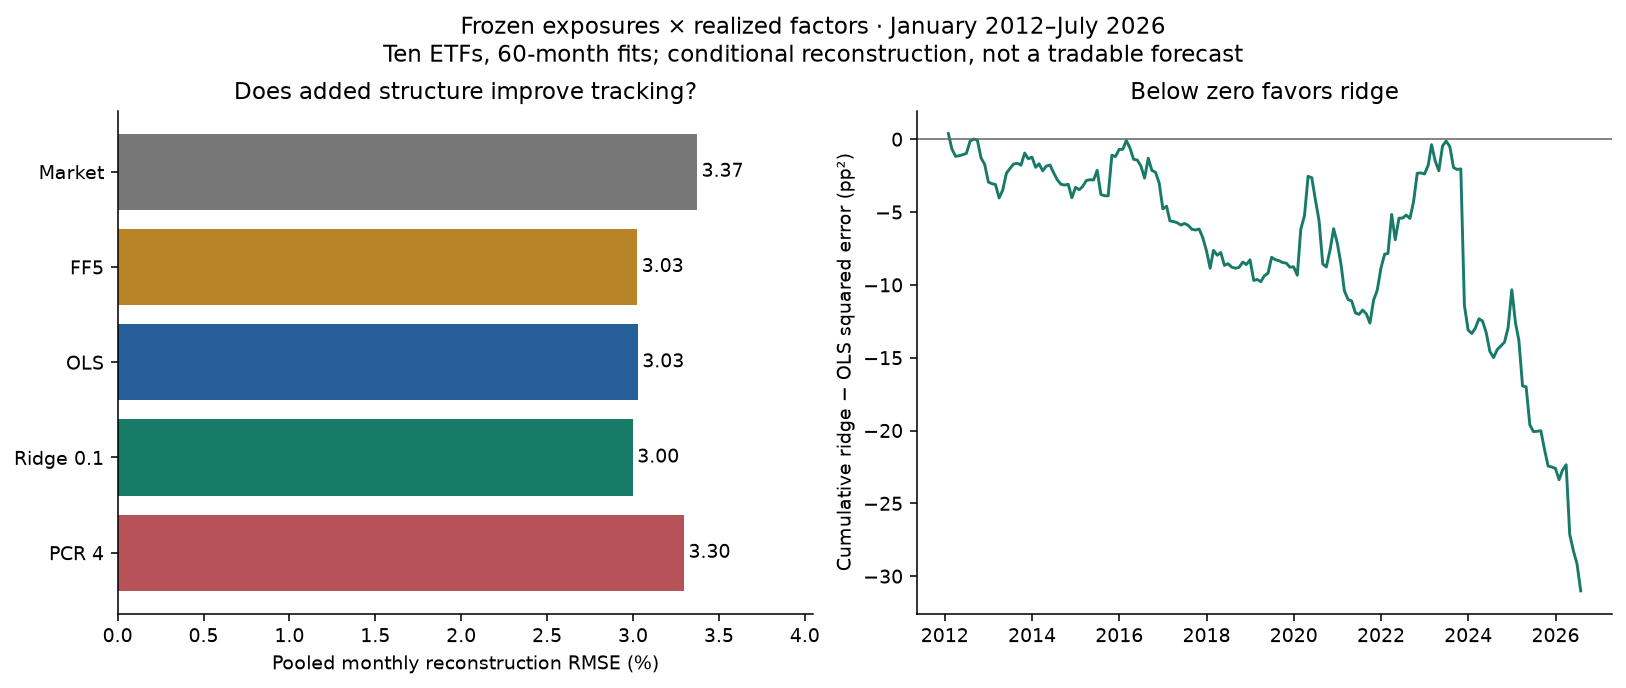

In [3]:
interval = comparison(paths)
display(pd.Series({k: interval[k] for k in ['estimate', 'lower95', 'upper95', 'relative_mse_reduction_pct', 'n']}).to_frame('Ridge minus OLS comparison'))
display(Image(filename=str(FIGURES / 'reconstruction.png')))

## Stable is not necessarily more accurate
The next figure uses all six raw slopes for the change statistic. PCR's lower dimensional subspace can move from one rolling fit to the next, so lower rank need not give smoother economic betas.

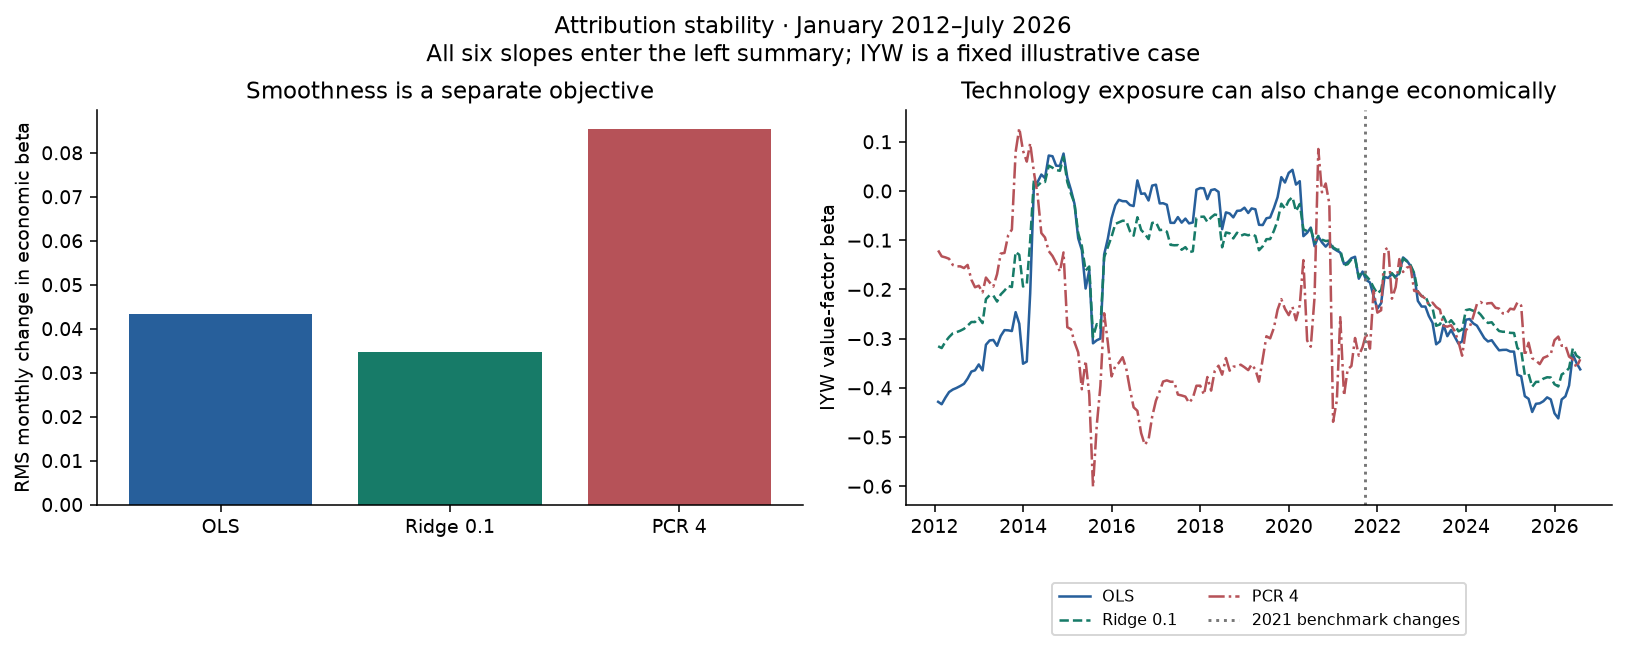

In [4]:
display(Image(filename=str(FIGURES / 'stability.png')))

## Retain the unfavorable sensitivities
Larger shrinkage can remove useful exposures. Compare every fixed penalty/rank, then compare windows on the same January 2017–July 2026 dates. These diagnostics do not replace the primary 60-month specification.

In [5]:
display(pd.read_csv(RESULTS / 'estimator_sensitivity.csv').round(4))
windows = pd.read_csv(RESULTS / 'window_sensitivity.csv')
display(windows[windows.scope.eq('common dates')][['window', 'estimate', 'lower95', 'upper95', 'relative_mse_reduction_pct']].round(4))

,model,months,etfs,rmse_pct_monthly,mse_pp2,rms_beta_monthly_change,mean_effective_df_including_intercept
0,Market,175,10,3.3741,11.3843,0.0090,2.0000
1,FF5,175,10,3.0256,9.1540,0.0407,6.0000
2,OLS,175,10,3.0288,9.1736,0.0434,7.0000
3,Ridge 0.1,175,10,2.9994,8.9964,0.0347,6.1530
4,PCR 4,175,10,3.2979,10.8761,0.0854,5.0000
5,Ridge 0.01,175,10,3.0193,9.1162,0.0421,6.8963
6,Ridge 1,175,10,3.5420,12.5455,0.0192,3.6272
7,PCR 3,175,10,3.8744,15.0113,0.0569,4.0000
8,PCR 5,175,10,3.0746,9.4533,0.0851,6.0000


,window,estimate,lower95,upper95,relative_mse_reduction_pct
1,60,-0.2281,-0.5568,0.0910,2.0916
3,36,-0.4810,-0.9291,-0.0912,4.1979
5,120,-0.1658,-0.4580,0.1262,1.5598


## Research decision
The primary interval spans zero. Ridge provides a useful controlled regularization example and smoother loadings, but this study does not establish a robust improvement in reconstruction. A shorter-window sensitivity supports a more favorable estimate; it remains supporting evidence after a fixed primary comparison. [Full results](../../docs/03-results.md) retain the complete record.